# LOO disagreement distribution — basis for v3qc cactus→PG swap decisions

**Created 2026-05-16.** Documents the empirical concordance distribution across 75 LOO-tested cactus founders and the decision to swap only **2** founders (5772 Set-1, 9947 Ped-0) from cactus → PG, rather than the 7 originally flagged by Fernando.

## Question

Fernando flagged 7 cactus assemblies as low quality (ONT coverage <20× or excessive heterozygosity). Do the flags predict actual disagreement with independent short-read PanGenie calls? Or are the flags false alarms?

## Metric

**Per-founder disagreement %** = `n_nonref_disc / n_nonref_either`, computed by `panel/pangenie_genotyping/scripts/loo_concordance.py` for each of 75 cactus founders genotyped from their 1001G short reads (`loo_*.tsv` summaries). Counts only sites where ≥1 of the two methods called ALT — REF/REF matches don't contribute.

## Headline

- Median disagreement across 75 founders: **4.14%**
- 4 of Fernando's 7 flagged founders fall **at or below the median** — flags do NOT predict assembly quality
- Real outliers (>15% disagreement): 6 founders, only 2 of which Fernando flagged (5772, 9947)
- 4 un-flagged founders (Hau-0, Mt-0, Aitba-1, Brö1-6) are in the extreme tail — could be more upstream mislabels like 5772, or PG-side issues; not investigated this session
- **Decision: swap only 5772 + 9947** (the cases with independent evidence of cactus-side issues). Trust Fernando's expert vetting for un-flagged founders even when PG-cactus disagree.

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LOO_DIR = '/global/scratch/users/tbellg/kmate/panel/pangenie_genotyping/data/loo_concordance'
FLAGGED = {'5772', '7298', '9416', '9518', '9542', '9564', '9947'}
FLAGGED_REASON = {
    '5772': 'Set-1 — Het: too many variants (mislabeled T980)',
    '7298': 'Pi-0 — Het ~4Mb in 3 blocks',
    '9416': 'Kru-3 — ONT ~15×',
    '9518': 'IP-Alm-0 — ONT ~11×',
    '9542': 'IP-Fun-0 — ONT ~14×',
    '9564': 'IP-Nog-17 — ONT ~9×',
    '9947': 'Ped-0 — ONT ~10×',
}

In [2]:
# Load all summary tsv files
rows = []
for f in sorted(glob.glob(f'{LOO_DIR}/*_summary.tsv')):
    acc = os.path.basename(f).split('_')[0]
    df = pd.read_csv(f, sep='\t')
    total_var = df['n_nonref_either'].sum()
    total_disc = df['n_nonref_disc'].sum()
    overall_pct = 100.0 * total_disc / total_var if total_var > 0 else np.nan
    per_class = {row['size_class']: 100.0 * row['n_nonref_disc'] / row['n_nonref_either']
                 if row['n_nonref_either'] > 0 else np.nan for _, row in df.iterrows()}
    per_class_counts = {f'n_{row["size_class"]}_var': row['n_nonref_either'] for _, row in df.iterrows()}
    per_class_counts.update({f'n_{row["size_class"]}_disc': row['n_nonref_disc'] for _, row in df.iterrows()})
    rows.append({
        'acc': acc,
        'total_var': total_var,
        'total_disc': total_disc,
        'overall_pct': overall_pct,
        'flagged': acc in FLAGGED,
        'flag_reason': FLAGGED_REASON.get(acc, ''),
        **per_class,
        **per_class_counts,
    })
data = pd.DataFrame(rows).sort_values('overall_pct').reset_index(drop=True)
print(f'Loaded {len(data)} founders')
data.head()

Loaded 75 founders


,acc,total_var,total_disc,overall_pct,flagged,flag_reason,SNP,small_indel,small_sv,medium_sv,...,n_SNP_var,n_small_indel_var,n_small_sv_var,n_medium_sv_var,n_large_sv_var,n_SNP_disc,n_small_indel_disc,n_small_sv_disc,n_medium_sv_disc,n_large_sv_disc
0,6932,1798788,32782,1.822449,False,,2.446406,2.641260,1.311493,0.575953,...,349247,698606,266109,376767,108059,8544,18452,3490,2170,126
1,7002,1726349,43438,2.516177,False,,3.226000,3.587805,1.727294,1.089643,...,333106,663191,256239,367001,106812,10746,23794,4426,3999,473
2,7288,1749498,45125,2.579311,False,,3.667143,3.666915,1.809238,0.825318,...,339665,672718,257567,372705,106843,12456,24668,4660,3076,265
3,6911,2159795,56356,2.609322,False,,3.257565,3.509079,2.184206,0.815430,...,489384,869117,296950,396110,108234,15942,30498,6486,3230,200
4,7025,1798660,53999,3.002179,False,,4.141702,4.094855,2.334553,1.167178,...,347490,694994,265447,381947,108782,14392,28459,6197,4458,493


In [3]:
# Distribution summary
stats = data['overall_pct'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95])
print('Distribution of overall disagreement %% across 75 LOO-tested founders:')
print(stats.round(2))
print('\nNatural break in the distribution:')
diffs = np.diff(sorted(data['overall_pct'].values))
big_jumps = sorted(zip(diffs, range(len(diffs))), reverse=True)[:5]
vals = sorted(data['overall_pct'].values)
for jump, idx in big_jumps:
    print(f'  gap of {jump:.2f}pp between {vals[idx]:.2f}% and {vals[idx+1]:.2f}%')

Distribution of overall disagreement %% across 75 LOO-tested founders:
count    75.00
mean      6.93
std       9.65
min       1.82
10%       3.06
25%       3.33
50%       4.14
75%       5.36
90%       8.58
95%      26.09
max      52.31
Name: overall_pct, dtype: float64

Natural break in the distribution:
  gap of 14.52pp between 30.34% and 44.86%
  gap of 7.71pp between 16.56% and 24.27%
  gap of 7.58pp between 8.98% and 16.56%
  gap of 6.07pp between 24.27% and 30.34%
  gap of 5.07pp between 44.86% and 49.93%


## Main plot — disagreement distribution with Fernando-flagged founders marked

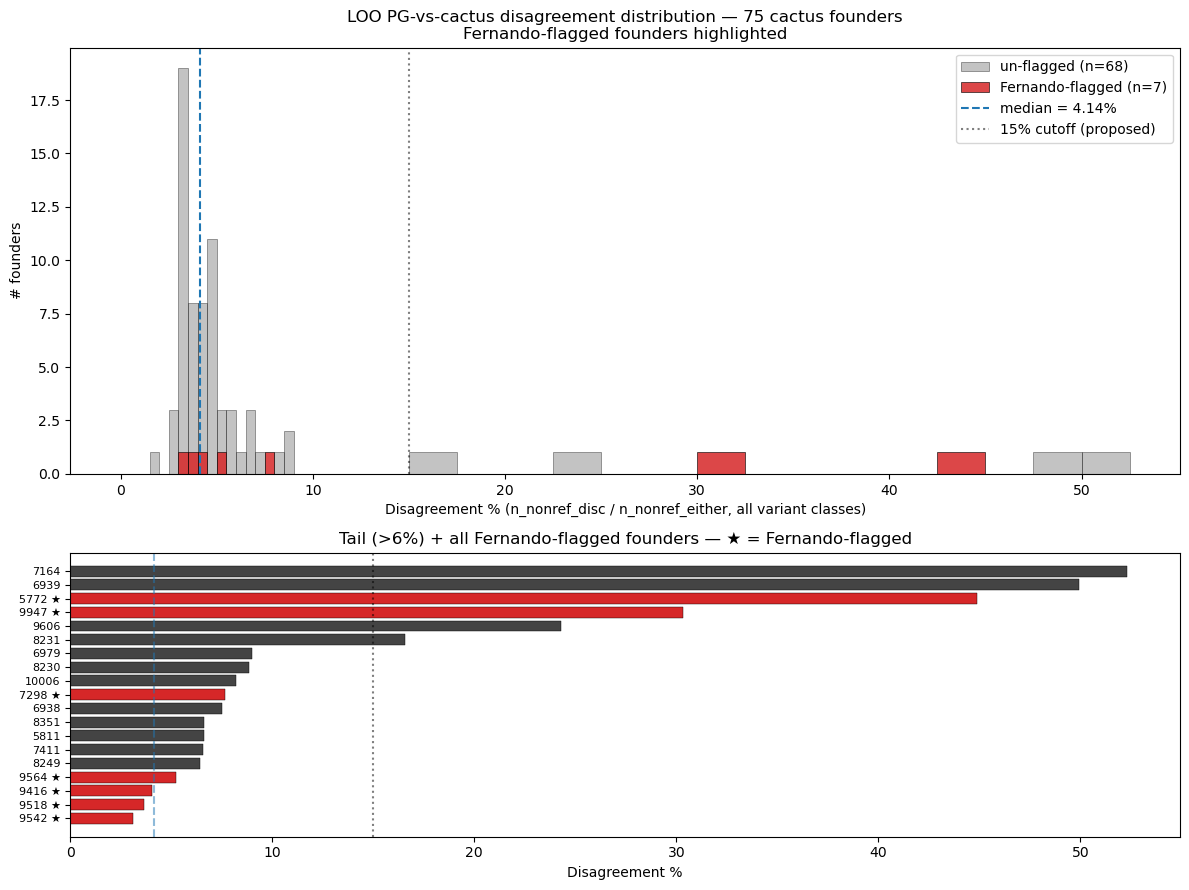

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [3, 2]})

# Panel 1: histogram + strip
ax = axes[0]
bins = np.concatenate([np.arange(0, 10, 0.5), np.arange(10, 55, 2.5)])
ax.hist(data.loc[~data.flagged, 'overall_pct'], bins=bins, color='#888888', alpha=0.5, label=f'un-flagged (n={(~data.flagged).sum()})', edgecolor='black', linewidth=0.5)
ax.hist(data.loc[data.flagged, 'overall_pct'], bins=bins, color='#d62728', alpha=0.85, label=f'Fernando-flagged (n={data.flagged.sum()})', edgecolor='black', linewidth=0.5)
ax.axvline(data['overall_pct'].median(), color='#1f77b4', linestyle='--', label=f"median = {data['overall_pct'].median():.2f}%")
ax.axvline(15.0, color='black', linestyle=':', alpha=0.5, label='15% cutoff (proposed)')
ax.set_xlabel('Disagreement % (n_nonref_disc / n_nonref_either, all variant classes)')
ax.set_ylabel('# founders')
ax.set_title('LOO PG-vs-cactus disagreement distribution — 75 cactus founders\nFernando-flagged founders highlighted')
ax.legend(loc='upper right')

# Panel 2: strip plot with names — sorted, only showing tail + flagged
ax = axes[1]
show = data[(data['overall_pct'] >= 6.0) | data['flagged']].sort_values('overall_pct').reset_index(drop=True)
y = np.arange(len(show))
colors = ['#d62728' if f else '#444444' for f in show['flagged']]
ax.barh(y, show['overall_pct'], color=colors, edgecolor='black', linewidth=0.3)
ax.set_yticks(y)
ax.set_yticklabels([f"{r.acc}{' ★' if r.flagged else ''}" for _, r in show.iterrows()], fontsize=8)
ax.axvline(15.0, color='black', linestyle=':', alpha=0.5)
ax.axvline(data['overall_pct'].median(), color='#1f77b4', linestyle='--', alpha=0.5)
ax.set_xlabel('Disagreement %')
ax.set_title('Tail (>6%) + all Fernando-flagged founders — ★ = Fernando-flagged')

plt.tight_layout()
plt.savefig('plots/LOO_DISAGREEMENT_DISTRIBUTION.png', dpi=150, bbox_inches='tight')
plt.show()

## What the plot shows

**Top panel (histogram):**
- The bulk of un-flagged founders (gray) cluster tightly in 2-6% disagreement.
- Fernando-flagged founders (red) are scattered across the full distribution — not concentrated in the tail.
- Only 2 of 7 Fernando-flagged founders (5772, 9947) sit in the catastrophic tail.
- 4 founders in the extreme tail (>15%) are NOT Fernando-flagged: Hau-0 (7164), Mt-0 (6939), Aitba-1 (9606), Brö1-6 (8231).

**Bottom panel (tail detail):**
- Shows all founders >6% + all Fernando-flagged.
- 5 of Fernando's 7 flags (★) live in or just above the normal distribution.
- The catastrophic >15% tail is the well-isolated cluster of 6: 7164, 6939, 5772, 9947, 9606, 8231.

## Per-size-class breakdown for the 7 Fernando-flagged founders

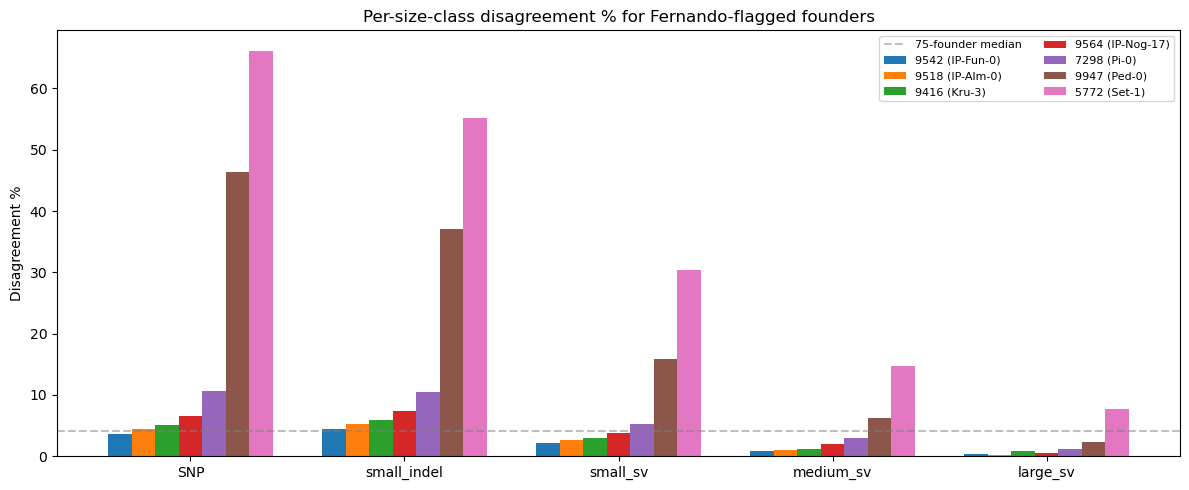

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
classes = ['SNP', 'small_indel', 'small_sv', 'medium_sv', 'large_sv']
x = np.arange(len(classes))
width = 0.11
flagged_data = data[data.flagged].sort_values('overall_pct').reset_index(drop=True)
for i, (_, row) in enumerate(flagged_data.iterrows()):
    vals = [row[c] for c in classes]
    ax.bar(x + i*width - 3*width, vals, width, label=f"{row.acc} ({row.flag_reason.split(' — ')[0]})")
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel('Disagreement %')
ax.set_title('Per-size-class disagreement % for Fernando-flagged founders')
ax.axhline(data['overall_pct'].median(), color='gray', linestyle='--', alpha=0.5, label='75-founder median')
ax.legend(ncol=2, loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('plots/LOO_DISAGREEMENT_BY_CLASS.png', dpi=150, bbox_inches='tight')
plt.show()

## Tail with decisions

Founders with >10% disagreement — the candidates for cactus→PG swap. Decision depends on whether there's **independent evidence** that the cactus side is the problem.

In [6]:
tail = data[data['overall_pct'] >= 10.0].sort_values('overall_pct', ascending=False).copy()
decisions = {
    '5772': ('SWAP to PG', 'Cactus FASTA mislabeled (cactus k-mer J=0.964 to T980; 1001G J=0.300). Independent evidence — Fernando flag confirmed by k-mer Jaccard.'),
    '9947': ('SWAP to PG', 'Fernando flag: ONT ~10× — independent a-priori evidence. Borderline (PG side is also 10× SE) but cactus errors are baked in; PG side filterable via GQ+V4.'),
    '7164': ('KEEP cactus', 'Hau-0 — NOT Fernando-flagged. No independent evidence of cactus-side issue. Could be mislabeling or PG-side issue. Investigate later via k-mer Jaccard if downstream eval flags it.'),
    '6939': ('KEEP cactus', 'Mt-0 — NOT Fernando-flagged. Same reasoning as Hau-0.'),
    '9606': ('KEEP cactus', 'Aitba-1 — NOT Fernando-flagged.'),
    '8231': ('KEEP cactus', 'Brö1-6 — NOT Fernando-flagged.'),
}
tail['decision'] = tail['acc'].map(lambda a: decisions.get(a, ('?', '?'))[0])
tail['rationale'] = tail['acc'].map(lambda a: decisions.get(a, ('', ''))[1])
display_cols = ['acc', 'total_var', 'total_disc', 'overall_pct', 'flagged', 'decision', 'rationale']
tail[display_cols]

,acc,total_var,total_disc,overall_pct,flagged,decision,rationale
74,7164,2666392,1394796,52.310238,False,KEEP cactus,Hau-0 — NOT Fernando-flagged. No independent e...
73,6939,2168347,1082620,49.928356,False,KEEP cactus,Mt-0 — NOT Fernando-flagged. Same reasoning as...
72,5772,2228335,999596,44.858426,True,SWAP to PG,Cactus FASTA mislabeled (cactus k-mer J=0.964 ...
71,9947,2420977,734435,30.336306,True,SWAP to PG,Fernando flag: ONT ~10× — independent a-priori...
70,9606,2355079,571574,24.269844,False,KEEP cactus,Aitba-1 — NOT Fernando-flagged.
69,8231,1968760,325991,16.558189,False,KEEP cactus,Brö1-6 — NOT Fernando-flagged.


## Final decision

**Swap 2 founders cactus→PG**: 5772 (Set-1), 9947 (Ped-0). Both have independent a-priori evidence (mislabel for 5772; Fernando coverage flag for 9947).

**Keep on cactus side**: 7164, 6939, 9606, 8231 (no independent evidence — trust Fernando's vetting). Plus 7298, 9564, 9416, 9518, 9542 (these had Fernando flags but empirical concordance proves the assemblies are fine).

**Net v3qc panel**: 78 cactus + 153 PG = 231 founders (no ecotype lost).

**Parking**: the 4 un-flagged tail founders (Hau-0, Mt-0, Aitba-1, Brö1-6) are candidates for follow-up k-mer-Jaccard mislabeling investigation. Not on the v3qc critical path; revisit only if downstream evaluation shows outliers concentrated on those specific founders.

## Outputs

- `LOO_DISAGREEMENT_DISTRIBUTION.png` — top-level distribution figure
- `LOO_DISAGREEMENT_BY_CLASS.png` — per-size-class breakdown for the 7 flagged